In [1]:
import os
import cv2
import matplotlib.pyplot as plt

In [10]:
# Original colour frames folder
input_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\frames\match1"

# Output colour frames with bordered player
output_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\Final_tracked_frames\match1"

# Final output video path
video_output_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\output_videos"
output_video_path = os.path.join(video_output_folder, "match1_player_tracking.mp4")

os.makedirs(output_folder, exist_ok=True)
os.makedirs(video_output_folder, exist_ok=True)

print("Input colour frames:", input_folder)
print("Output bordered colour frames:", output_folder)
print("Output video:", output_video_path)

Input colour frames: C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\frames\match1
Output bordered colour frames: C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\Final_tracked_frames\match1
Output video: C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\output_videos\match1_player_tracking.mp4


In [11]:
frame_files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith((".jpg"))
])

if not frame_files:
    raise ValueError("No colour frames found in input folder.")

print("Total colour frames:", len(frame_files))
print("First frame:", frame_files[0])
print("Last frame:", frame_files[-1])

Total colour frames: 164
First frame: frame_0000.jpg
Last frame: frame_0163.jpg


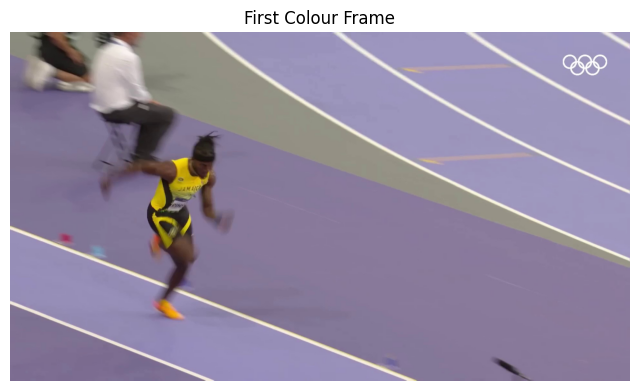

Frame size: 1920 x 1080


In [4]:
first_frame_path = os.path.join(input_folder, frame_files[0])
first_frame = cv2.imread(first_frame_path)

if first_frame is None:
    raise ValueError("Could not read first colour frame.")

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.title("First Colour Frame")
plt.axis("off")
plt.show()

height, width = first_frame.shape[:2]
print("Frame size:", width, "x", height)

In [12]:
bbox = cv2.selectROI("Select Player on Colour Frame", first_frame, fromCenter=False, showCrosshair=True)
cv2.destroyAllWindows()

if bbox == (0, 0, 0, 0):
    raise ValueError("No player selected. Please run this cell again and select the player.")

print("Selected bounding box:", bbox)

Selected bounding box: (230, 251, 532, 589)


In [13]:
# Different OpenCV versions support CSRT in different places
if hasattr(cv2, "legacy") and hasattr(cv2.legacy, "TrackerCSRT_create"):
    tracker = cv2.legacy.TrackerCSRT_create()
elif hasattr(cv2, "TrackerCSRT_create"):
    tracker = cv2.TrackerCSRT_create()
else:
    raise AttributeError("CSRT tracker not available. Install opencv-contrib-python.")

tracker.init(first_frame, bbox)
print("CSRT tracker initialized successfully.")

CSRT tracker initialized successfully.


In [14]:
border_color = (0, 255, 0)      # Green border in BGR format
text_color = (0, 255, 0)
border_thickness = 3

saved_count = 0

for file in frame_files:
    frame_path = os.path.join(input_folder, file)
    frame = cv2.imread(frame_path)

    if frame is None:
        print("Skipping unreadable frame:", file)
        continue

    success, box = tracker.update(frame)
    output = frame.copy()

    if success:
        x, y, w, h = [int(v) for v in box]

        # Draw player border
        cv2.rectangle(output, (x, y), (x + w, y + h), border_color, border_thickness)

        # Add small label
        cv2.putText(output, "Player", (x, max(25, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, text_color, 2)
    else:
        cv2.putText(output, "Tracking Failure", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    cv2.imwrite(os.path.join(output_folder, file), output)
    saved_count += 1

print("Tracking completed.")
print("Saved bordered colour frames:", saved_count)
print("Output folder:", output_folder)

Tracking completed.
Saved bordered colour frames: 164
Output folder: C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\Final_tracked_frames\match1


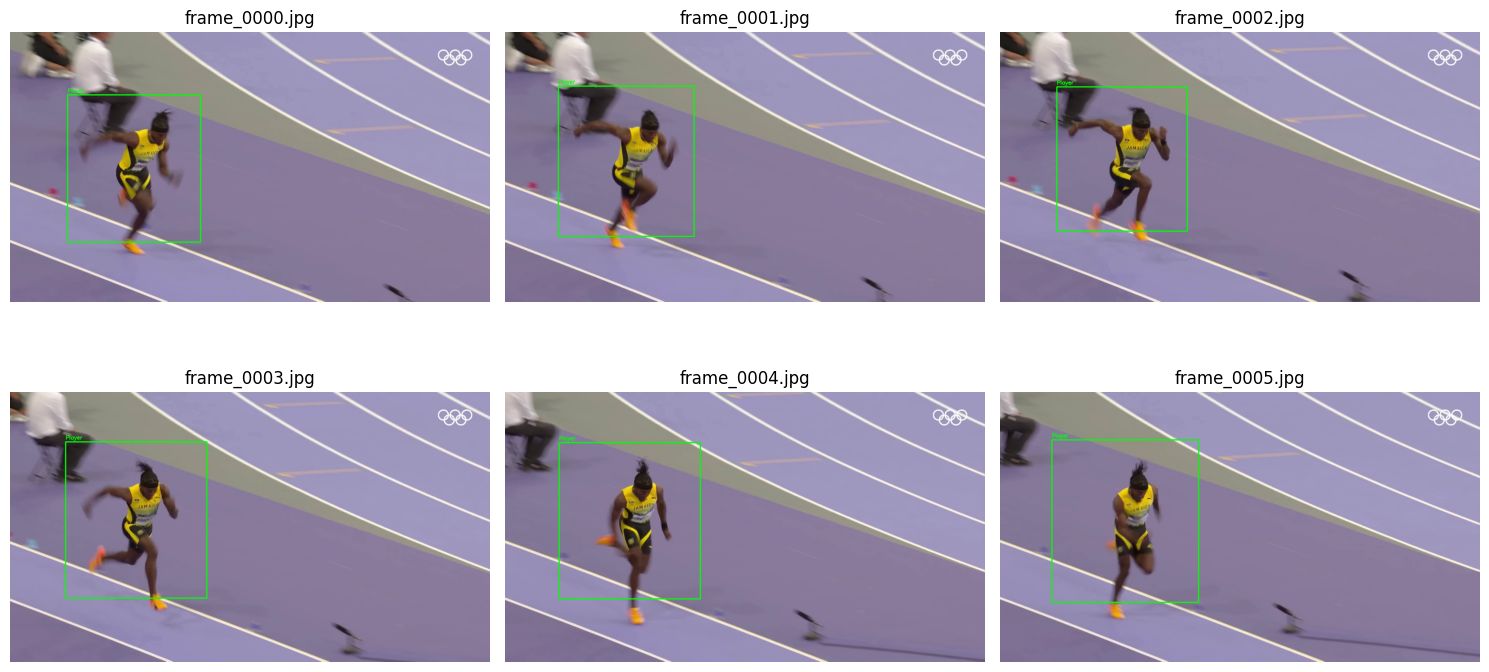

In [15]:
sample_files = frame_files[:6]

plt.figure(figsize=(15, 8))

for i, file in enumerate(sample_files):
    img_path = os.path.join(output_folder, file)
    img = cv2.imread(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
fps = 30

bordered_frame_files = sorted([
    f for f in os.listdir(output_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

if not bordered_frame_files:
    raise ValueError("No bordered colour frames found. Run Step 6 first.")

first_output_frame = cv2.imread(os.path.join(output_folder, bordered_frame_files[0]))
if first_output_frame is None:
    raise ValueError("Could not read first bordered colour frame.")

h, w = first_output_frame.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

for file in bordered_frame_files:
    frame = cv2.imread(os.path.join(output_folder, file))

    if frame is None:
        print("Skipping unreadable output frame:", file)
        continue

    # Make sure every frame has the same size
    if frame.shape[:2] != (h, w):
        frame = cv2.resize(frame, (w, h))

    video_writer.write(frame)

video_writer.release()

print("Colour bordered player video created successfully!")
print("Saved video path:", output_video_path)
print("FPS:", fps)
print("Video size:", w, "x", h)

Colour bordered player video created successfully!
Saved video path: C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\output_videos\match1_player_tracking.mp4
FPS: 30
Video size: 1920 x 1080
